In [1]:
import torch
import torchvision.datasets as datasets
from tqdm import tqdm
from torch import nn, optim
from torchvision import transforms
from torchvision.utils import save_image
from torch.utils.data import DataLoader
from model import VAE

In [2]:
x = torch.randn(4, 28*28)
model = VAE(input_dim=28*28)
x_reconstructed, mu, sigma = model(x)

In [3]:
# config
device = "mps"
input_dim = 28*28
h_dim = 200
z_dim = 20
epochs = 10
batch_size = 128
lr = 3e-4

# load mnist
dataset = datasets.MNIST(root="../AEs/data", train=True, transform=transforms.ToTensor(), download=True)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Model
model = VAE(input_dim=input_dim, h_dim=h_dim, z_dim=z_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.BCELoss(reduction="sum")

In [4]:
losses = []
outputs = []

device = "mps"
model.to(device)

# Calculate total number of batches for progress bar
total_batches = epochs * len(train_loader)
# Create a single progress bar for all training steps
with tqdm(total=total_batches, desc="Training", unit="batch") as pbar:
    for epoch in range(epochs):
        epoch_loss = 0
        for batch_idx, (x, y) in enumerate(train_loader):
            x = x.to(device).view(x.shape[0], -1)
            x_reconstructed, mu, sigma = model(x)

            # Compute Loss
            reconstruction_loss = loss_fn(x_reconstructed, x)
            # Ensure sigma is positive by applying softplus (or exp) and adding epsilon for numerical stability
            sigma_pos = torch.nn.functional.softplus(sigma) + 1e-6
            q = torch.distributions.Normal(mu, sigma_pos)
            p = torch.distributions.Normal(torch.zeros_like(mu), torch.ones_like(sigma_pos))
            kl_div = torch.distributions.kl_divergence(q, p).sum()
            loss = reconstruction_loss + kl_div

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())
            epoch_loss += loss.item()

            # Update progress bar with current loss
            pbar.set_postfix({
                'Epoch': f'{epoch+1}/{epochs}',
                'Batch': f'{batch_idx+1}/{len(train_loader)}',
                'Loss': f'{loss.item():.6f}',
                'Avg Loss': f'{epoch_loss/(batch_idx+1):.6f}'
            })
            pbar.update(1)

        # Store output from last batch of each epoch
        outputs.append(x_reconstructed.cpu().detach().numpy())

Training: 100%|██████████| 4690/4690 [01:11<00:00, 65.89batch/s, Epoch=10/10, Batch=469/469, Loss=8185.624512, Avg Loss=11178.264806] 


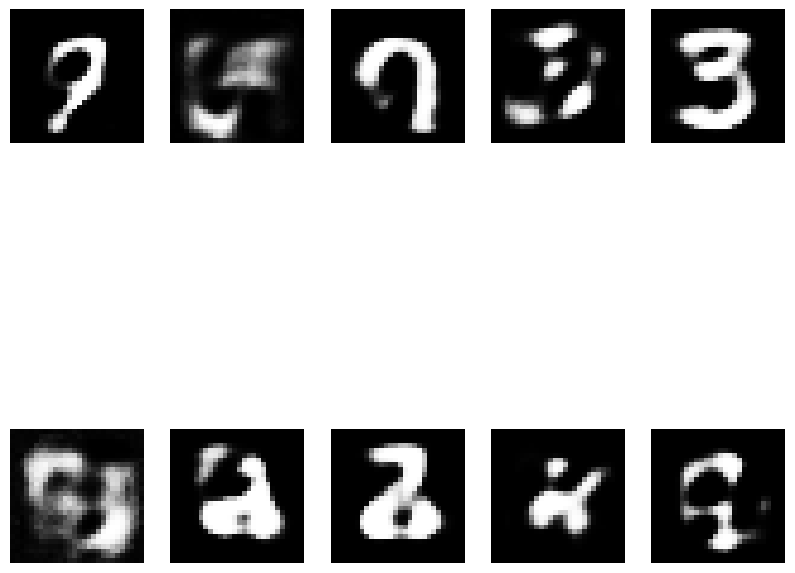

In [5]:
import matplotlib.pyplot as plt
# Try to sample with random gaussian noise
z = torch.randn(10, z_dim).to(device)
with torch.no_grad():
    x_reconstructed = model.decode(z)
# visualize the reconstructed images
plt.figure(figsize=(10, 10))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_reconstructed[i].cpu().numpy().reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.show()